In [14]:
from pathlib import Path
import numpy as np
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm

from IPPy import operators
from IPPy.utilities import gaussian_noise

from utils.data_utils import load_normalized_image

# Input
TRAIN_DIR = Path("../dataset_resized/train_resized")
VALIDATION_DIR = Path("../dataset_resized/validation_resized")
TEST_DIR = Path("../dataset_resized/test_resized")

# Output dei sinogrammi
SINOGRAMS_DIR = Path("../sinograms")
SINOGRAMS_DIR.mkdir(parents=True, exist_ok=True)


# Configurazioni Limited-Angle CT (in GRADI, come prima)
ANGLE_CONFIGS = {
    90: np.linspace(-45, 45, 90),
    45: np.linspace(-45, 45, 45),
    30: np.linspace(-30, 30, 32)[1:-1],
    15: np.linspace(-30, 30, 17)[1:-1],
}

NOISE_LEVEL = 0.005
SEED = 42
IMG_SIZE = (256, 256)

# Un CTProjector per ciascuna configurazione, creato UNA VOLTA sola
# (costruire l'operatore ASTRA ha un costo: non va rifatto per ogni immagine)
PROJECTORS = {
    n_angles: operators.CTProjector(
        img_shape=IMG_SIZE,
        angles=np.deg2rad(angles),   # conversione gradi -> radianti
        geometry="parallel",
        force_cpu=True,
    )
    for n_angles, angles in ANGLE_CONFIGS.items()
}

Attempting to create ASTRA projector type: 'linear' for 'parallel' geometry...
Successfully created ASTRA projector type: 'linear'
CTProjector initialized. Geometry: parallel. Using GPU: False. FBP Algorithm: FBP
Attempting to create ASTRA projector type: 'linear' for 'parallel' geometry...
Successfully created ASTRA projector type: 'linear'
CTProjector initialized. Geometry: parallel. Using GPU: False. FBP Algorithm: FBP
Attempting to create ASTRA projector type: 'linear' for 'parallel' geometry...
Successfully created ASTRA projector type: 'linear'
CTProjector initialized. Geometry: parallel. Using GPU: False. FBP Algorithm: FBP
Attempting to create ASTRA projector type: 'linear' for 'parallel' geometry...
Successfully created ASTRA projector type: 'linear'
CTProjector initialized. Geometry: parallel. Using GPU: False. FBP Algorithm: FBP


In [2]:
def generate_sinograms(input_root: Path, output_root: Path, projectors: dict,
                        noise_level: float, seed: int):
    """
    Per ogni immagine dentro input_root, genera un sinogramma rumoroso
    (tramite gli operatori CTProjector di IPPy) per ciascuna configurazione
    angolare in projectors, e lo salva come .npy dentro
    output_root/<n_angoli>/<stessa struttura sottocartelle>.
    """
    torch.manual_seed(seed)   # seed UNA volta sola, non per immagine (stesso motivo di prima)
    image_paths = sorted(input_root.rglob("*.png"))

    for image_path in tqdm(image_paths, desc=f"Sinogrammi da {input_root.name}"):
        rel_path = image_path.relative_to(input_root)

        image = load_normalized_image(image_path)              # numpy (256,256), [0,1]
        x = torch.from_numpy(image).float().unsqueeze(0).unsqueeze(0)  # (1,1,256,256)

        for n_angles, K in projectors.items():
            out_path = (output_root / str(n_angles) / rel_path).with_suffix(".npy")
            out_path.parent.mkdir(parents=True, exist_ok=True)

            if out_path.exists():
                continue

            sinogram = K(x)                                     # (1,1,n_angoli,det_size)
            noise = gaussian_noise(sinogram, noise_level)
            sinogram_noisy = sinogram + noise

            np.save(out_path, sinogram_noisy.squeeze().numpy().astype(np.float32))


generate_sinograms(TRAIN_DIR, SINOGRAMS_DIR / "train", PROJECTORS, NOISE_LEVEL, SEED)
generate_sinograms(VALIDATION_DIR, SINOGRAMS_DIR / "validation", PROJECTORS, NOISE_LEVEL, SEED)
generate_sinograms(TEST_DIR, SINOGRAMS_DIR / "test", PROJECTORS, NOISE_LEVEL, SEED)

print("Generazione sinogrammi completata.")

Sinogrammi da test_resized: 100%|██████████| 327/327 [00:21<00:00, 15.33it/s]

Generazione sinogrammi completata.


File: ..\sinograms\test\90\C081\0.npy
shape: (90, 364)
min: -0.6287132 max: 59.1806


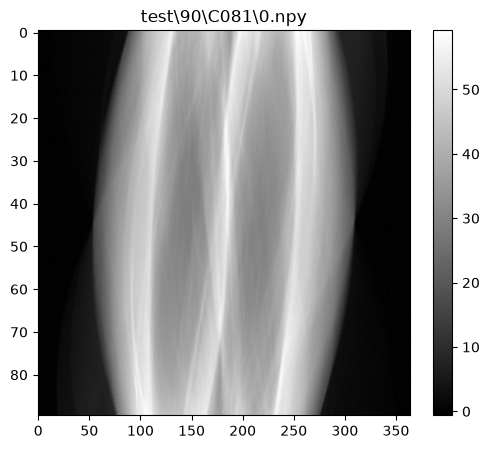

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# Trova il primo sinogramma disponibile nel test set (qualunque configurazione)
sino_path = sorted((SINOGRAMS_DIR / "test" / "90").rglob("*.npy"))[0]
print("File:", sino_path)

sinogram = np.load(sino_path)
print("shape:", sinogram.shape)
print("min:", sinogram.min(), "max:", sinogram.max())

plt.figure(figsize=(6, 5))
plt.imshow(sinogram, cmap="gray", aspect="auto")
plt.title(sino_path.relative_to(SINOGRAMS_DIR))
plt.colorbar()
plt.show()